In [1]:
!pip install seaborn


[notice] A new release of pip is available: 23.0 -> 23.0.1
[notice] To update, run: C:\Users\hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [65]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import dash
from dash import html,dcc,Output,Input
import warnings
warnings.filterwarnings("ignore")


In [66]:
pd.options.display.max_rows=300
pd.options.display.max_columns=50


df1=pd.read_csv("cars_data1.csv")
df2=pd.read_csv("cars_data2.csv")
df3=pd.read_csv("cars_data3.csv")
df4=pd.read_csv("cars_data4.csv")
df5=pd.read_csv("cars_data5.csv")
df6=pd.read_csv("cars_data6.csv")
df7=pd.read_csv("cars_data7.csv")
df8=pd.read_csv("cars_data8.csv")
df9=pd.read_csv("cars_data10.csv")
df10=pd.read_csv("cars_data11.csv")
df11=pd.read_csv("cars_data12.csv")
df12=pd.read_csv("cars_data13.csv")
df13=pd.read_csv("cars_data14.csv")
df14=pd.read_csv("cars_data16.csv")
cars_data=pd.concat([df1,df2,df3,df4,df5,df6,df7,df8,df9,df10,df11,df12,df13,df14],ignore_index=True)
cars_data.head()


In [67]:
#cars_data.to_csv("cars_data.csv")
cars_data=pd.read_csv("cars_data.csv")
cars_data.drop_duplicates(inplace=True)
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25126 entries, 0 to 25125
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0.1                      25126 non-null  int64  
 1   Unnamed: 0                        25126 non-null  int64  
 2   mark_model                        25126 non-null  object 
 3   Year                              25126 non-null  int64  
 4   Power                             25126 non-null  object 
 5   Location                          25126 non-null  object 
 6   Kilométrage                       22451 non-null  object 
 7   Boite_de_vitesses                 25121 non-null  object 
 8   Date                              25126 non-null  object 
 9   Puissance_fiscale                 23130 non-null  float64
 10  Nombre_de_portes                  21011 non-null  float64
 11  Première_main                     9246 non-null   object 
 12  Coul

In [68]:
#convert "Kilométrage" type to "int"
cars_data["Kilométrage"]=cars_data["Kilométrage"].str.replace(" ","")
cars_data["Kilométrage"]=cars_data["Kilométrage"].replace(np.nan,0)
cars_data["Kilométrage"]=cars_data["Kilométrage"].astype(int)
#cars_data["Kilométrage"]

In [69]:

cars_data["Prices"]=cars_data["Prices"].str.replace("Dhs","").replace(" ","")
cars_data["Prices"]=cars_data["Prices"].str.replace(" ","")
# drop rows with none price value
cars_data.dropna(subset=["Prices"],inplace=True)
#convert " Prices" type to integer
cars_data[["Prices"]]=cars_data[["Prices"]].astype(int)

In [6]:
#drop unusefull columns
cars_data.drop(columns=["Unnamed: 0.1","Unnamed: 0"],inplace=True)

In [70]:
# reset index
cars_data.reset_index(drop=True,inplace=True)
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24693 entries, 0 to 24692
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0.1                      24693 non-null  int64  
 1   Unnamed: 0                        24693 non-null  int64  
 2   mark_model                        24693 non-null  object 
 3   Year                              24693 non-null  int64  
 4   Power                             24693 non-null  object 
 5   Location                          24693 non-null  object 
 6   Kilométrage                       24693 non-null  int32  
 7   Boite_de_vitesses                 24688 non-null  object 
 8   Date                              24693 non-null  object 
 9   Puissance_fiscale                 22761 non-null  float64
 10  Nombre_de_portes                  20649 non-null  float64
 11  Première_main                     8941 non-null   object 
 12  Coul

In [71]:
#set "Première_main" as integer
cars_data["Première_main"]=cars_data["Première_main"].str.replace("Oui","1").replace(np.nan,0)
cars_data["Première_main"]=cars_data["Première_main"].astype("int64")

In [72]:
# convert"Power" to 2 dummies 1:""
power=cars_data["Power"].value_counts().to_frame()
power

,Power
Diesel,20629
Essence,4007
Hybride,54
Electrique,3


In [78]:
px.bar(x=power.index,y=power["Power"],color=power.index,barmode="overlay")

In [79]:
power_dummies=pd.get_dummies(cars_data["Power"])
power_dummies.rename(columns={"Diesel":"Diesel_Power","Electrique":"Electrique_Power",
                              "Essence":"Essence_Power","Hybride":"Hybride_Power"},inplace=True)


In [80]:
cars_data=pd.concat([cars_data,power_dummies],axis=1)

In [13]:
#cars_data.drop(columns=["Diesel_Power","Electrique_Power","Essence_Power","Hybride_Power"],axis=0,inplace=True)

In [81]:
cars_data.head()

,Unnamed: 0.1,Unnamed: 0,mark_model,Year,Power,Location,Kilométrage,Boite_de_vitesses,Date,Puissance_fiscale,Nombre_de_portes,Première_main,Couleur,Carrosserie,Prices,Dvd_cd_mp3,Jantes_aluminium,Airbags,Climatisation_auto,Abs,Vitres_éléctriques,Esp,Intérieur_cuir,Ordinateur_de_bord,Alarme,...,Système_de_navigation_gps,Anti_patinage,Projecteurs_xenon,Rétroviseur_extérieur_électrique,Toit_ouvrant,Siége_electrique,Siège_chauffant,Siége_sport,Volant_reglable,Anti_démarrage,Volant_sport,Contrôle_de_pression_des_pneus,Détecteur_de_pluie,Climatisation_multizone,Keyless_go,Radio_commande_au_volant,Régulateur_de_vitesse,Anti_brouillard,Affichage_tête_haute,Suspension_sport,Frein_de_parking_automatique,Diesel_Power,Electrique_Power,Essence_Power,Hybride_Power
0,0,0,RENAULT R19,1993,Diesel,Beni mellal,34000,Manuelle,02-06-2021,5.0,4.0,0,Vert fonce,Compact,37000,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
1,3,3,PEUGEOT 203,1956,Essence,Casablanca,0,Manuelle,17-06-2022,7.0,5.0,0,Rouge fonce,Compact,130000,1,1,1,1,1,1,0,0,1,1,...,0,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,0,1,0,1,1,0,0,1,0
2,4,4,PEUGEOT 206,2002,Diesel,Chefchaouen,300000,Manuelle,31-01-2022,7.0,5.0,0,Noir,Citadine,45000,1,1,1,1,1,1,0,0,1,1,...,0,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,0,1,0,1,1,1,0,0,0
3,5,5,ALFA-ROMEO 159,2007,Essence,El jadida,137000,Manuelle,25-10-2022,11.0,5.0,0,Noir,Berline,57000,1,1,1,1,1,1,1,0,1,1,...,0,1,1,1,0,0,0,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0,1,0
4,6,6,NISSAN Micra,2021,Diesel,Casablanca,70000,Manuelle,19-07-2022,6.0,5.0,1,Bordeaux,Citadine,158000,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0


In [82]:
cars_data.drop(columns=["Power"],axis=0,inplace=True)

In [83]:
cars_data.describe()

,Unnamed: 0.1,Unnamed: 0,Year,Kilométrage,Puissance_fiscale,Nombre_de_portes,Première_main,Prices,Dvd_cd_mp3,Jantes_aluminium,Airbags,Climatisation_auto,Abs,Vitres_éléctriques,Esp,Intérieur_cuir,Ordinateur_de_bord,Alarme,Aide_parking,Système_de_navigation_gps,Anti_patinage,Projecteurs_xenon,Rétroviseur_extérieur_électrique,Toit_ouvrant,Siége_electrique,Siège_chauffant,Siége_sport,Volant_reglable,Anti_démarrage,Volant_sport,Contrôle_de_pression_des_pneus,Détecteur_de_pluie,Climatisation_multizone,Keyless_go,Radio_commande_au_volant,Régulateur_de_vitesse,Anti_brouillard,Affichage_tête_haute,Suspension_sport,Frein_de_parking_automatique,Diesel_Power,Electrique_Power,Essence_Power,Hybride_Power
count,24693.000000,24693.000000,24693.000000,2.469300e+04,22761.000000,20649.000000,24693.000000,2.469300e+04,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000,24693.000000
mean,12592.932127,1698.126757,2010.751225,2.789160e+05,7.605202,4.777132,0.362086,1.317172e+05,0.998826,0.999231,0.999271,0.999109,0.999271,0.999231,0.998340,0.997894,0.998866,0.999271,0.998056,0.998259,0.998340,0.996234,0.998421,0.989430,0.997449,0.996153,0.995464,0.998866,0.998218,0.997125,0.998016,0.998097,0.997854,0.992953,0.998907,0.998947,0.998947,0.989633,0.993925,0.997651,0.835419,0.000121,0.162273,0.002187
std,7245.173431,1816.227638,6.864524,1.423551e+07,2.499827,0.629353,0.480613,1.115151e+05,0.034250,0.027729,0.026990,0.029836,0.026990,0.027729,0.040715,0.045842,0.033655,0.026990,0.044047,0.041694,0.040715,0.061255,0.039711,0.102267,0.050447,0.061908,0.067196,0.033655,0.042176,0.053546,0.044503,0.043587,0.046280,0.083649,0.033050,0.032432,0.032432,0.101293,0.077704,0.048409,0.370810,0.011022,0.368708,0.046714
min,0.000000,0.000000,1940.000000,0.000000e+00,2.000000,2.000000,0.000000,9.000000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6305.000000,459.000000,2007.000000,6.900000e+04,6.000000,5.000000,0.000000,6.800000e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,12583.000000,1019.000000,2012.000000,1.330000e+05,7.000000,5.000000,0.000000,1.050000e+05,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,18892.000000,2036.000000,2016.000000,1.990000e+05,8.000000,5.000000,1.000000,1.600000e+05,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,25125.000000,7413.000000,2023.000000,2.147484e+09,60.000000,10.000000,1.000000,3.900000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00

In [84]:
cars_data.drop(columns=["Date"],index=0,inplace=True)
#Puissance_fiscale

In [85]:
cars_data.drop_duplicates(inplace=True)

In [89]:
cars_data.index=range(24277)

ValueError: Length mismatch: Expected axis has 24692 elements, new values have 24277 elements

In [87]:
cars_data.shape

(24692, 49)

In [88]:
cars_data.rename(columns={"Prices":"Price"},inplace=True)
cars_data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'mark_model', 'Year', 'Location',
       'Kilométrage', 'Boite_de_vitesses', 'Puissance_fiscale',
       'Nombre_de_portes', 'Première_main', 'Couleur', 'Carrosserie', 'Price',
       'Dvd_cd_mp3', 'Jantes_aluminium', 'Airbags', 'Climatisation_auto',
       'Abs', 'Vitres_éléctriques', 'Esp', 'Intérieur_cuir',
       'Ordinateur_de_bord', 'Alarme', 'Aide_parking',
       'Système_de_navigation_gps', 'Anti_patinage', 'Projecteurs_xenon',
       'Rétroviseur_extérieur_électrique', 'Toit_ouvrant', 'Siége_electrique',
       'Siège_chauffant', 'Siége_sport', 'Volant_reglable', 'Anti_démarrage',
       'Volant_sport', 'Contrôle_de_pression_des_pneus', 'Détecteur_de_pluie',
       'Climatisation_multizone', 'Keyless_go', 'Radio_commande_au_volant',
       'Régulateur_de_vitesse', 'Anti_brouillard', 'Affichage_tête_haute',
       'Suspension_sport', 'Frein_de_parking_automatique', 'Diesel_Power',
       'Electrique_Power', 'Essence_Power', 'Hybride_Power']

In [90]:
cars_data["Boite_de_vitesses"].value_counts()
cars_data["Boite_de_vitesses"].replace(np.nan,"Manuelle",inplace=True)
cars_data["Boite_de_vitesses"].isna().value_counts()


False    24692
Name: Boite_de_vitesses, dtype: int64

In [91]:
auto_man=pd.get_dummies(cars_data["Boite_de_vitesses"])
#cars_data=pd.concat([cars_data,auto_man],axis=1)
#cars_data.drop(columns=["Automatique","Manuelle"],axis=0,inplace=True)

In [92]:
cars_data=pd.concat([cars_data,auto_man],axis=1)
cars_data.head()

,Unnamed: 0.1,Unnamed: 0,mark_model,Year,Location,Kilométrage,Boite_de_vitesses,Puissance_fiscale,Nombre_de_portes,Première_main,Couleur,Carrosserie,Price,Dvd_cd_mp3,Jantes_aluminium,Airbags,Climatisation_auto,Abs,Vitres_éléctriques,Esp,Intérieur_cuir,Ordinateur_de_bord,Alarme,Aide_parking,Système_de_navigation_gps,...,Projecteurs_xenon,Rétroviseur_extérieur_électrique,Toit_ouvrant,Siége_electrique,Siège_chauffant,Siége_sport,Volant_reglable,Anti_démarrage,Volant_sport,Contrôle_de_pression_des_pneus,Détecteur_de_pluie,Climatisation_multizone,Keyless_go,Radio_commande_au_volant,Régulateur_de_vitesse,Anti_brouillard,Affichage_tête_haute,Suspension_sport,Frein_de_parking_automatique,Diesel_Power,Electrique_Power,Essence_Power,Hybride_Power,Automatique,Manuelle
1,3,3,PEUGEOT 203,1956,Casablanca,0,Manuelle,7.0,5.0,0,Rouge fonce,Compact,130000,1,1,1,1,1,1,0,0,1,1,1,0,...,0,0,0,0,0,1,1,1,1,0,1,1,1,1,0,1,0,1,1,0,0,1,0,0,1
2,4,4,PEUGEOT 206,2002,Chefchaouen,300000,Manuelle,7.0,5.0,0,Noir,Citadine,45000,1,1,1,1,1,1,0,0,1,1,1,0,...,0,0,0,0,0,1,1,1,1,0,1,1,1,1,0,1,0,1,1,1,0,0,0,0,1
3,5,5,ALFA-ROMEO 159,2007,El jadida,137000,Manuelle,11.0,5.0,0,Noir,Berline,57000,1,1,1,1,1,1,1,0,1,1,1,0,...,1,1,0,0,0,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0,1,0,0,1
4,6,6,NISSAN Micra,2021,Casablanca,70000,Manuelle,6.0,5.0,1,Bordeaux,Citadine,158000,1,1,1,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0,0,1
5,9,9,HYUNDAI Santa fe,2016,Casablanca,155000,Automatique,9.0,5.0,1,Noir,Suv et 4x4,225000,1,1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,1,0


In [93]:
cars_data.drop(columns=["Boite_de_vitesses"],axis=0,inplace=True)
cars_data.head()

,Unnamed: 0.1,Unnamed: 0,mark_model,Year,Location,Kilométrage,Puissance_fiscale,Nombre_de_portes,Première_main,Couleur,Carrosserie,Price,Dvd_cd_mp3,Jantes_aluminium,Airbags,Climatisation_auto,Abs,Vitres_éléctriques,Esp,Intérieur_cuir,Ordinateur_de_bord,Alarme,Aide_parking,Système_de_navigation_gps,Anti_patinage,Projecteurs_xenon,Rétroviseur_extérieur_électrique,Toit_ouvrant,Siége_electrique,Siège_chauffant,Siége_sport,Volant_reglable,Anti_démarrage,Volant_sport,Contrôle_de_pression_des_pneus,Détecteur_de_pluie,Climatisation_multizone,Keyless_go,Radio_commande_au_volant,Régulateur_de_vitesse,Anti_brouillard,Affichage_tête_haute,Suspension_sport,Frein_de_parking_automatique,Diesel_Power,Electrique_Power,Essence_Power,Hybride_Power,Automatique,Manuelle
1,3,3,PEUGEOT 203,1956,Casablanca,0,7.0,5.0,0,Rouge fonce,Compact,130000,1,1,1,1,1,1,0,0,1,1,1,0,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,0,1,0,1,1,0,0,1,0,0,1
2,4,4,PEUGEOT 206,2002,Chefchaouen,300000,7.0,5.0,0,Noir,Citadine,45000,1,1,1,1,1,1,0,0,1,1,1,0,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,0,1,0,1,1,1,0,0,0,0,1
3,5,5,ALFA-ROMEO 159,2007,El jadida,137000,11.0,5.0,0,Noir,Berline,57000,1,1,1,1,1,1,1,0,1,1,1,0,1,1,1,0,0,0,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0,1,0,0,1
4,6,6,NISSAN Micra,2021,Casablanca,70000,6.0,5.0,1,Bordeaux,Citadine,158000,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0,0,1
5,9,9,HYUNDAI Santa fe,2016,Casablanca,155000,9.0,5.0,1,Noir,Suv et 4x4,225000,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,1,0


In [94]:
cars_data.columns
cars_data.reindex(columns=['mark_model', 'Year', 'Location', 'Kilométrage', 'Puissance_fiscale',
       'Nombre_de_portes', 'Première_main', 'Couleur', 'Carrosserie',
       'Dvd_cd_mp3', 'Jantes_aluminium', 'Airbags', 'Climatisation_auto',
       'Abs', 'Vitres_éléctriques', 'Esp', 'Intérieur_cuir',
       'Ordinateur_de_bord', 'Alarme', 'Aide_parking',
       'Système_de_navigation_gps', 'Anti_patinage', 'Projecteurs_xenon',
       'Rétroviseur_extérieur_électrique', 'Toit_ouvrant', 'Siége_electrique',
       'Siège_chauffant', 'Siége_sport', 'Volant_reglable', 'Anti_démarrage',
       'Volant_sport', 'Contrôle_de_pression_des_pneus', 'Détecteur_de_pluie',
       'Climatisation_multizone', 'Keyless_go', 'Radio_commande_au_volant',
       'Régulateur_de_vitesse', 'Anti_brouillard', 'Affichage_tête_haute',
       'Suspension_sport', 'Frein_de_parking_automatique', 'Diesel_Power',
       'Electrique_Power', 'Essence_Power', 'Hybride_Power', 'Automatique',
       'Manuelle', 'Price'])
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24692 entries, 1 to 24692
Data columns (total 50 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0.1                      24692 non-null  int64  
 1   Unnamed: 0                        24692 non-null  int64  
 2   mark_model                        24692 non-null  object 
 3   Year                              24692 non-null  int64  
 4   Location                          24692 non-null  object 
 5   Kilométrage                       24692 non-null  int32  
 6   Puissance_fiscale                 22760 non-null  float64
 7   Nombre_de_portes                  20648 non-null  float64
 8   Première_main                     24692 non-null  int64  
 9   Couleur                           23043 non-null  object 
 10  Carrosserie                       24304 non-null  object 
 11  Price                             24692 non-null  int32  
 12  Dvd_

In [95]:
cars_data["Puissance_fiscale"].mean()
#Nombre_de_portes                
#Première_main                      
#Couleur                         
#Carrosserie                      

7.605316344463972

In [96]:
# replace nan values in "Puissance_fiscale" by the mean:

Wfisc_count=cars_data["Puissance_fiscale"].value_counts().to_frame()
Wfisc_count
#for i in Wfisc_count["Puissance_fiscale"]:
mean_=sum(Wfisc_count.index*Wfisc_count["Puissance_fiscale"])/sum(Wfisc_count["Puissance_fiscale"])
cars_data["Puissance_fiscale"].replace(np.nan,int(cars_data["Puissance_fiscale"].mean()),inplace=True)
#cars_data["Puissance_fiscale"].isna().value_counts()


In [97]:
# replace nan values in "Nombre_de_portes" by the mean:
cars_data["Nombre_de_portes"].mean()# the mean too far to 5
cars_data["Nombre_de_portes"].replace(np.nan,5,inplace=True)
cars_data["Nombre_de_portes"].isna().value_counts()

False    24692
Name: Nombre_de_portes, dtype: int64

In [98]:
# replace nan values in "Couleur" by the "Autre":
cars_colors=cars_data["Couleur"].value_counts().to_frame()
cars_colors
#px.pie(cars_colors,names=cars_colors.index,values="Couleur",color=cars_colors.index,opacity=0.7)
#cars_data["Couleur"].isna().value_counts()
#groupbycolor=cars_data[["Couleur","Price"]].groupby("Couleur").mean()
#groupbycolor.sort_values(by="Price",ascending=False)
cars_data["Couleur"].replace(np.nan,"Autre",inplace=True)

In [99]:
cars_data["Carrosserie"].isna().value_counts()

False    24304
True       388
Name: Carrosserie, dtype: int64

In [100]:
cars_data["Carrosserie"].value_counts()

Berline                 7227
Suv et 4x4              4634
Citadine                4287
Compact                 3526
Monospace               1263
Utilitaire (minivan)    1233
Coupé                    661
Utilitaire (van)         413
Crossover                337
Pick up​                 270
Micro-citadine           181
Break                    158
Cabriolet                 76
Cc                        38
Name: Carrosserie, dtype: int64

In [33]:
#cars_data.to_csv("cars_data_with_Carrosserie_missing_values.csv")

In [102]:
#drop rows with Caroossserie missing values

cars_data.dropna(subset=["Carrosserie"],inplace=True)
cars_data.index=range(24304)

In [35]:
#cars_data.to_csv("cars_data_No_missing_values.csv")

In [103]:
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24304 entries, 0 to 24303
Data columns (total 50 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0.1                      24304 non-null  int64  
 1   Unnamed: 0                        24304 non-null  int64  
 2   mark_model                        24304 non-null  object 
 3   Year                              24304 non-null  int64  
 4   Location                          24304 non-null  object 
 5   Kilométrage                       24304 non-null  int32  
 6   Puissance_fiscale                 24304 non-null  float64
 7   Nombre_de_portes                  24304 non-null  float64
 8   Première_main                     24304 non-null  int64  
 9   Couleur                           24304 non-null  object 
 10  Carrosserie                       24304 non-null  object 
 11  Price                             24304 non-null  int32  
 12  Dvd_

In [104]:
#set all int type values as float
cars_data.columns
cars_data[['Year', 'Kilométrage', 'Puissance_fiscale',
       'Nombre_de_portes', 'Première_main','Price',
       'Dvd_cd_mp3', 'Jantes_aluminium', 'Airbags', 'Climatisation_auto',
       'Abs', 'Vitres_éléctriques', 'Esp', 'Intérieur_cuir',
       'Ordinateur_de_bord', 'Alarme', 'Aide_parking',
       'Système_de_navigation_gps', 'Anti_patinage', 'Projecteurs_xenon',
       'Rétroviseur_extérieur_électrique', 'Toit_ouvrant', 'Siége_electrique',
       'Siège_chauffant', 'Siége_sport', 'Volant_reglable', 'Anti_démarrage',
       'Volant_sport', 'Contrôle_de_pression_des_pneus', 'Détecteur_de_pluie',
       'Climatisation_multizone', 'Keyless_go', 'Radio_commande_au_volant',
       'Régulateur_de_vitesse', 'Anti_brouillard', 'Affichage_tête_haute',
       'Suspension_sport', 'Frein_de_parking_automatique', 'Diesel_Power',
       'Electrique_Power', 'Essence_Power', 'Hybride_Power', 'Automatique',
       'Manuelle']]=cars_data[['Year', 'Kilométrage', 'Puissance_fiscale',
       'Nombre_de_portes', 'Première_main','Price',
       'Dvd_cd_mp3', 'Jantes_aluminium', 'Airbags', 'Climatisation_auto',
       'Abs', 'Vitres_éléctriques', 'Esp', 'Intérieur_cuir',
       'Ordinateur_de_bord', 'Alarme', 'Aide_parking',
       'Système_de_navigation_gps', 'Anti_patinage', 'Projecteurs_xenon',
       'Rétroviseur_extérieur_électrique', 'Toit_ouvrant', 'Siége_electrique',
       'Siège_chauffant', 'Siége_sport', 'Volant_reglable', 'Anti_démarrage',
       'Volant_sport', 'Contrôle_de_pression_des_pneus', 'Détecteur_de_pluie',
       'Climatisation_multizone', 'Keyless_go', 'Radio_commande_au_volant',
       'Régulateur_de_vitesse', 'Anti_brouillard', 'Affichage_tête_haute',
       'Suspension_sport', 'Frein_de_parking_automatique', 'Diesel_Power',
       'Electrique_Power', 'Essence_Power', 'Hybride_Power', 'Automatique',
       'Manuelle']].astype(float)
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24304 entries, 0 to 24303
Data columns (total 50 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0.1                      24304 non-null  int64  
 1   Unnamed: 0                        24304 non-null  int64  
 2   mark_model                        24304 non-null  object 
 3   Year                              24304 non-null  float64
 4   Location                          24304 non-null  object 
 5   Kilométrage                       24304 non-null  float64
 6   Puissance_fiscale                 24304 non-null  float64
 7   Nombre_de_portes                  24304 non-null  float64
 8   Première_main                     24304 non-null  float64
 9   Couleur                           24304 non-null  object 
 10  Carrosserie                       24304 non-null  object 
 11  Price                             24304 non-null  float64
 12  Dvd_

In [105]:
# replace 0 values in "Kilomètrage" by mean:
mean_kilo=cars_data["Kilométrage"].mean()
mean_kilo
cars_data["Kilométrage"].replace(0,mean_kilo,inplace=True)
(cars_data["Kilométrage"]==0).value_counts()


False    24304
Name: Kilométrage, dtype: int64

In [106]:
cars_data.head()

,Unnamed: 0.1,Unnamed: 0,mark_model,Year,Location,Kilométrage,Puissance_fiscale,Nombre_de_portes,Première_main,Couleur,Carrosserie,Price,Dvd_cd_mp3,Jantes_aluminium,Airbags,Climatisation_auto,Abs,Vitres_éléctriques,Esp,Intérieur_cuir,Ordinateur_de_bord,Alarme,Aide_parking,Système_de_navigation_gps,Anti_patinage,Projecteurs_xenon,Rétroviseur_extérieur_électrique,Toit_ouvrant,Siége_electrique,Siège_chauffant,Siége_sport,Volant_reglable,Anti_démarrage,Volant_sport,Contrôle_de_pression_des_pneus,Détecteur_de_pluie,Climatisation_multizone,Keyless_go,Radio_commande_au_volant,Régulateur_de_vitesse,Anti_brouillard,Affichage_tête_haute,Suspension_sport,Frein_de_parking_automatique,Diesel_Power,Electrique_Power,Essence_Power,Hybride_Power,Automatique,Manuelle
0,3,3,PEUGEOT 203,1956.0,Casablanca,260717.780736,7.0,5.0,0.0,Rouge fonce,Compact,130000.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,4,4,PEUGEOT 206,2002.0,Chefchaouen,300000.000000,7.0,5.0,0.0,Noir,Citadine,45000.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2,5,5,ALFA-ROMEO 159,2007.0,El jadida,137000.000000,11.0,5.0,0.0,Noir,Berline,57000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,6,6,NISSAN Micra,2021.0,Casablanca,70000.000000,6.0,5.0,1.0,Bordeaux,Citadine,158000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,9,9,HYUNDAI Santa fe,2016.0,Casablanca,155000.000000,9.0,5.0,1.0,Noir,Suv et 4x4,225000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


In [107]:
#Mark and Model
Made=[]
Model=[]
Class=[]
mark_model=list(cars_data["mark_model"])
for i in mark_model:
        n=i.split()
        Made.append(n[0]) 
        try:
            Model.append(n[1]+" "+n[2])
        except:
            Model.append(n[1])
print(len(Made),len(Model))



24304 24304


In [108]:
cars_data["Made"]=Made
cars_data["Model"]=Model
cars_data.head()

,Unnamed: 0.1,Unnamed: 0,mark_model,Year,Location,Kilométrage,Puissance_fiscale,Nombre_de_portes,Première_main,Couleur,Carrosserie,Price,Dvd_cd_mp3,Jantes_aluminium,Airbags,Climatisation_auto,Abs,Vitres_éléctriques,Esp,Intérieur_cuir,Ordinateur_de_bord,Alarme,Aide_parking,Système_de_navigation_gps,Anti_patinage,...,Toit_ouvrant,Siége_electrique,Siège_chauffant,Siége_sport,Volant_reglable,Anti_démarrage,Volant_sport,Contrôle_de_pression_des_pneus,Détecteur_de_pluie,Climatisation_multizone,Keyless_go,Radio_commande_au_volant,Régulateur_de_vitesse,Anti_brouillard,Affichage_tête_haute,Suspension_sport,Frein_de_parking_automatique,Diesel_Power,Electrique_Power,Essence_Power,Hybride_Power,Automatique,Manuelle,Made,Model
0,3,3,PEUGEOT 203,1956.0,Casablanca,260717.780736,7.0,5.0,0.0,Rouge fonce,Compact,130000.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,PEUGEOT,203
1,4,4,PEUGEOT 206,2002.0,Chefchaouen,300000.000000,7.0,5.0,0.0,Noir,Citadine,45000.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,PEUGEOT,206
2,5,5,ALFA-ROMEO 159,2007.0,El jadida,137000.000000,11.0,5.0,0.0,Noir,Berline,57000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,ALFA-ROMEO,159
3,6,6,NISSAN Micra,2021.0,Casablanca,70000.000000,6.0,5.0,1.0,Bordeaux,Citadine,158000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,NISSAN,Micra
4,9,9,HYUNDAI Santa fe,2016.0,Casablanca,155000.000000,9.0,5.0,1.0,Noir,Suv et 4x4,225000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,HYUNDAI,Santa fe


In [109]:
#cars_data.drop(columns=["Boite_de_vitesses"],axis=0,inplace=True)
cars_data=cars_data.reindex(columns=['mark_model','Made','Model','Year', 'Location', 'Kilométrage', 'Boite_de_vitesses',
       'Puissance_fiscale', 'Nombre_de_portes', 'Première_main', 'Couleur',
       'Carrosserie', 'Price', 'Dvd_cd_mp3', 'Jantes_aluminium', 'Airbags',
       'Climatisation_auto', 'Abs', 'Vitres_éléctriques', 'Esp',
       'Intérieur_cuir', 'Ordinateur_de_bord', 'Alarme', 'Aide_parking',
       'Système_de_navigation_gps', 'Anti_patinage', 'Projecteurs_xenon',
       'Rétroviseur_extérieur_électrique', 'Toit_ouvrant', 'Siége_electrique',
       'Siège_chauffant', 'Siége_sport', 'Volant_reglable', 'Anti_démarrage',
       'Volant_sport', 'Contrôle_de_pression_des_pneus', 'Détecteur_de_pluie',
       'Climatisation_multizone', 'Keyless_go', 'Radio_commande_au_volant',
       'Régulateur_de_vitesse', 'Anti_brouillard', 'Affichage_tête_haute',
       'Suspension_sport', 'Frein_de_parking_automatique', 'Diesel_Power',
       'Electrique_Power', 'Essence_Power', 'Hybride_Power', 'Automatique',
       'Manuelle'])
#cars_data.drop(columns=["mark_model"],inplace=True)
cars_data.head()

,mark_model,Made,Model,Year,Location,Kilométrage,Boite_de_vitesses,Puissance_fiscale,Nombre_de_portes,Première_main,Couleur,Carrosserie,Price,Dvd_cd_mp3,Jantes_aluminium,Airbags,Climatisation_auto,Abs,Vitres_éléctriques,Esp,Intérieur_cuir,Ordinateur_de_bord,Alarme,Aide_parking,Système_de_navigation_gps,...,Projecteurs_xenon,Rétroviseur_extérieur_électrique,Toit_ouvrant,Siége_electrique,Siège_chauffant,Siége_sport,Volant_reglable,Anti_démarrage,Volant_sport,Contrôle_de_pression_des_pneus,Détecteur_de_pluie,Climatisation_multizone,Keyless_go,Radio_commande_au_volant,Régulateur_de_vitesse,Anti_brouillard,Affichage_tête_haute,Suspension_sport,Frein_de_parking_automatique,Diesel_Power,Electrique_Power,Essence_Power,Hybride_Power,Automatique,Manuelle
0,PEUGEOT 203,PEUGEOT,203,1956.0,Casablanca,260717.780736,NaN,7.0,5.0,0.0,Rouge fonce,Compact,130000.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,PEUGEOT 206,PEUGEOT,206,2002.0,Chefchaouen,300000.000000,NaN,7.0,5.0,0.0,Noir,Citadine,45000.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2,ALFA-ROMEO 159,ALFA-ROMEO,159,2007.0,El jadida,137000.000000,NaN,11.0,5.0,0.0,Noir,Berline,57000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,NISSAN Micra,NISSAN,Micra,2021.0,Casablanca,70000.000000,NaN,6.0,5.0,1.0,Bordeaux,Citadine,158000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,HYUNDAI Santa fe,HYUNDAI,Santa fe,2016.0,Casablanca,155000.000000,NaN,9.0,5.0,1.0,Noir,Suv et 4x4,225000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


In [110]:
cars_data.drop(columns="Boite_de_vitesses",inplace=True)

In [111]:
cars_data.columns
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24304 entries, 0 to 24303
Data columns (total 50 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   mark_model                        24304 non-null  object 
 1   Made                              24304 non-null  object 
 2   Model                             24304 non-null  object 
 3   Year                              24304 non-null  float64
 4   Location                          24304 non-null  object 
 5   Kilométrage                       24304 non-null  float64
 6   Puissance_fiscale                 24304 non-null  float64
 7   Nombre_de_portes                  24304 non-null  float64
 8   Première_main                     24304 non-null  float64
 9   Couleur                           24304 non-null  object 
 10  Carrosserie                       24304 non-null  object 
 11  Price                             24304 non-null  float64
 12  Dvd_

In [112]:
sum_options_by_car=cars_data[['Dvd_cd_mp3', 'Jantes_aluminium', 'Airbags',
       'Climatisation_auto', 'Abs', 'Vitres_éléctriques', 'Esp',
       'Intérieur_cuir', 'Ordinateur_de_bord', 'Alarme', 'Aide_parking',
       'Système_de_navigation_gps', 'Anti_patinage', 'Projecteurs_xenon',
       'Rétroviseur_extérieur_électrique', 'Toit_ouvrant', 'Siége_electrique',
       'Siège_chauffant', 'Siége_sport', 'Volant_reglable', 'Anti_démarrage',
       'Volant_sport', 'Contrôle_de_pression_des_pneus', 'Détecteur_de_pluie',
       'Climatisation_multizone', 'Keyless_go', 'Radio_commande_au_volant',
       'Régulateur_de_vitesse', 'Anti_brouillard', 'Affichage_tête_haute',
       'Suspension_sport', 'Frein_de_parking_automatique']].sum(axis=1)
options_count=sum_options_by_car.value_counts()


In [113]:
options_count.to_frame()

,0
32.0,23905
31.0,169
30.0,58
29.0,45
27.0,27
26.0,14
20.0,11
0.0,10
24.0,9
25.0,7


we can see that 98 of cars have all the features(options)

In [123]:
sum_options_by_option=cars_data[['Dvd_cd_mp3', 'Jantes_aluminium', 'Airbags',
       'Climatisation_auto', 'Abs', 'Vitres_éléctriques', 'Esp',
       'Intérieur_cuir', 'Ordinateur_de_bord', 'Alarme', 'Aide_parking',
       'Système_de_navigation_gps', 'Anti_patinage', 'Projecteurs_xenon',
       'Rétroviseur_extérieur_électrique', 'Toit_ouvrant', 'Siége_electrique',
       'Siège_chauffant', 'Siége_sport', 'Volant_reglable', 'Anti_démarrage',
       'Volant_sport', 'Contrôle_de_pression_des_pneus', 'Détecteur_de_pluie',
       'Climatisation_multizone', 'Keyless_go', 'Radio_commande_au_volant',
       'Régulateur_de_vitesse', 'Anti_brouillard', 'Affichage_tête_haute',
       'Suspension_sport', 'Frein_de_parking_automatique']].sum(axis=0)
sum_options_by_option.sort_values()

Toit_ouvrant                        24050.0
Affichage_tête_haute                24052.0
Keyless_go                          24134.0
Suspension_sport                    24157.0
Siége_sport                         24194.0
Siège_chauffant                     24211.0
Projecteurs_xenon                   24212.0
Volant_sport                        24234.0
Siége_electrique                    24242.0
Frein_de_parking_automatique        24247.0
Climatisation_multizone             24252.0
Intérieur_cuir                      24253.0
Contrôle_de_pression_des_pneus      24256.0
Aide_parking                        24257.0
Détecteur_de_pluie                  24258.0
Anti_démarrage                      24261.0
Système_de_navigation_gps           24262.0
Esp                                 24264.0
Anti_patinage                       24264.0
Rétroviseur_extérieur_électrique    24266.0
Dvd_cd_mp3                          24275.0
Volant_reglable                     24276.0
Ordinateur_de_bord              

In [124]:
Fiesta=cars_data[cars_data["Model"]=="Fiesta" ]
Fiesta2008=Fiesta[Fiesta["Year"]==2008]
Fiesta2008_ess=Fiesta2008[Fiesta2008["Essence_Power"]==1]["Kilométrage"]==131000
cars_data.loc[4704]

mark_model                          FIAT Freemont
Made                                         FIAT
Model                                    Freemont
Year                                       2014.0
Location                                Marrakech
Kilométrage                               35961.0
Puissance_fiscale                             8.0
Nombre_de_portes                              5.0
Première_main                                 1.0
Couleur                                      Noir
Carrosserie                            Suv et 4x4
Price                                    190000.0
Dvd_cd_mp3                                    1.0
Jantes_aluminium                              1.0
Airbags                                       1.0
Climatisation_auto                            1.0
Abs                                           1.0
Vitres_éléctriques                            1.0
Esp                                           1.0
Intérieur_cuir                                1.0


In [116]:
cars_data.loc[504]

mark_model                                RENAULT Kangoo
Made                                             RENAULT
Model                                             Kangoo
Year                                              2005.0
Location                                          Agadir
Kilométrage                                     270000.0
Puissance_fiscale                                    7.0
Nombre_de_portes                                     5.0
Première_main                                        0.0
Couleur                                            Blanc
Carrosserie                         Utilitaire (minivan)
Price                                            65000.0
Dvd_cd_mp3                                           1.0
Jantes_aluminium                                     1.0
Airbags                                              1.0
Climatisation_auto                                   1.0
Abs                                                  1.0
Vitres_éléctriques             

#### lets see the top cars locations 

In [117]:
#!pip install folium

In [118]:
import folium
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import dash 
from dash import html,dcc,Output,Input

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


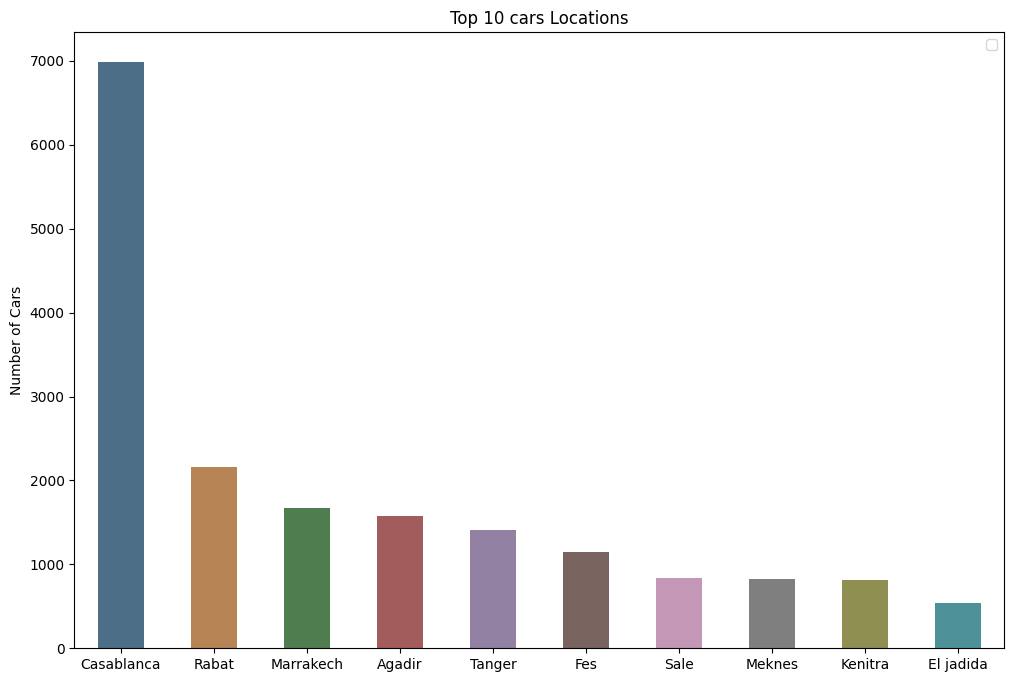

In [119]:
cars_loc=cars_data["Location"].value_counts().to_frame()
cars_loc.columns=["Location"]
top_cars_loc=cars_loc.head(10)
plt.figure(figsize=(12,8))
sns.barplot(top_cars_loc,x=top_cars_loc.index,y="Location",saturation=0.4,width=0.5)
plt.title("Top 10 cars Locations")
plt.ylabel("Number of Cars")
plt.legend()

### Question: How the made and model affect the price ?

#### lets creat some vizual for price, made and model

In [120]:
Made_modle_affect=cars_data[["Made","Model","Price"]]

In [121]:
count_made=pd.DataFrame(Made_modle_affect["Made"].value_counts()).head(30)
count_made=count_made.rename(columns={"Made":"Number_of_cars"})
count_made["Made"]=list(count_made.index)
count_made.index=range(len(count_made.index))
count_made

,Number_of_cars,Made
0,3205,VOLKSWAGEN
1,2667,RENAULT
2,2091,PEUGEOT
3,1976,MERCEDES
4,1685,FORD
5,1590,DACIA
6,1305,HYUNDAI
7,1093,FIAT
8,1048,CITROEN
9,885,AUDI


In [125]:
px.pie(count_made,
       values="Number_of_cars",
       names="Made",
       width=900,
       height=900,
      title="Portion of each made",
  )

In [126]:
price_grpby_made=Made_modle_affect.groupby("Made").mean().sort_values(by="Price",ascending=False)

price_grpby_made=price_grpby_made.iloc[3:30]


In [130]:
px.bar(price_grpby_made,x=price_grpby_made.index,y="Price",color=price_grpby_made.index)

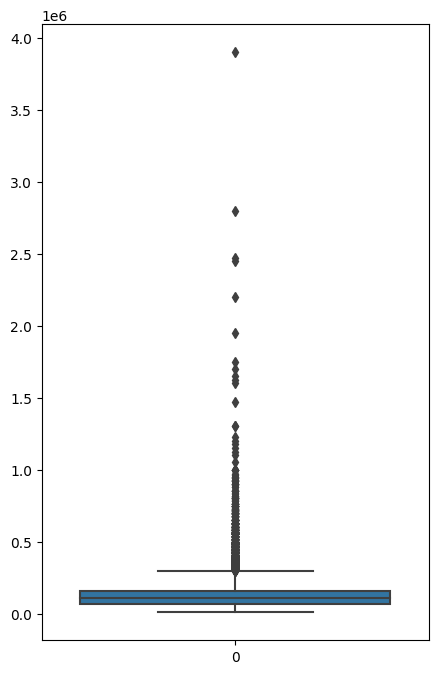

In [131]:
plt.figure(figsize=(5,8))
sns.boxplot(cars_data["Price"])
plt.show()
px.box(cars_data["Price"])

In [132]:
cars_data[["Location","Price","Year"]]

,Location,Price,Year
0,Casablanca,130000.0,1956.0
1,Chefchaouen,45000.0,2002.0
2,El jadida,57000.0,2007.0
3,Casablanca,158000.0,2021.0
4,Casablanca,225000.0,2016.0
...,...,...,...
24299,Oujda,30000.0,2000.0
24300,Azemmour,100000.0,2014.0
24301,Rabat,180000.0,2009.0
24302,Casablanca,118000.0,2013.0


In [133]:
price_by_loc=cars_data[["Year","Location","Price"]].groupby(["Year","Location"]).mean().sort_values(by="Price",ascending=False)
price_by_loc=pd.pivot_table(price_by_loc,index=["Year"],columns=["Location"],values="Price")                                                                                         
#top5_loc=price_by_loc.head(100)
#top5_loc
price_by_loc
#.plot(kind="area")
#plt.show
#top5_loc=pd.pivot_table(top5_loc,index=["Year"],columns=["Location"],values="Price")

Location,Agadir,Ait benhaddou,Ait daoud,Ait ourir,Al hoceima,Amizmiz,Arfoud,Asilah,Autre,Azemmour,Azrou,Ben ahmed,Ben slimane,Benguerir,Beni mellal,Berkane,Berrechid,Bouskoura,Bouznika,Casablanca,Chefchaouen,Chemaia,Chichaoua,Dakhla,Dar bouazza,...,Settat,Sidi bou othmane,Sidi kacem,Sidi rahal,Sidi slimane,Skhirat,Smara,Tahannaout,Taliouine,Tamanar,Tan-tan,Tanger,Taounate,Taourirte,Tarfaya,Taroudannt,Tata,Taza,Temara,Tetouan,Tiflet,Tinghir,Tiznit,Youssoufia,Zagora
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1940.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1954.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1955.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1956.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130000.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1968.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50000.000000,NaN,NaN,NaN,NaN,NaN
1969.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,230000.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
price_by_loc["Agadir"]

In [134]:
ax1=px.area(price_by_loc)

<Axes: ylabel='Frequency'>

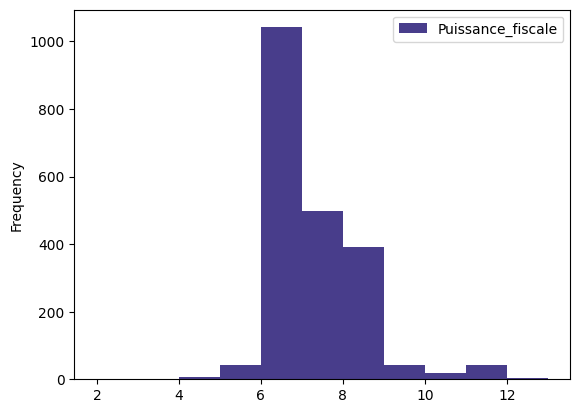

In [138]:

PEUGEOT_cars=cars_data[cars_data["Made"]=="PEUGEOT"]
PEUGEOT_cars=PEUGEOT_cars[["Made","Puissance_fiscale"]]
PEUGEOT_cars.value_counts()
PEUGEOT_cars.plot(kind="hist",
                 color='darkslateblue',
                 bins=11)
#PEUGEOT_cars.plot(kind="kde")

In [ ]:
count


In [139]:
PEUGEOT_cars_val=PEUGEOT_cars.value_counts().to_frame()
PEUGEOT_cars_val=PEUGEOT_cars_val.reset_index().drop(["Made"],axis=1)
PEUGEOT_cars_val.rename(columns={0:"Count"},inplace=True)
px.histogram(PEUGEOT_cars_val,
             y="Count",x="Puissance_fiscale"
             ,orientation="v"
             ,nbins=11
             ,histfunc='sum')

In [ ]:
PEUGEOT_cars_val

In [140]:
Carross_count=cars_data[["Carrosserie"]].value_counts().to_frame()
Carross_count.reset_index(inplace=True)
Carross_count.rename(columns={0:"Count"},inplace=True)
Carross_count

,Carrosserie,Count
0,Berline,7227
1,Suv et 4x4,4634
2,Citadine,4287
3,Compact,3526
4,Monospace,1263
5,Utilitaire (minivan),1233
6,Coupé,661
7,Utilitaire (van),413
8,Crossover,337
9,Pick up​,270


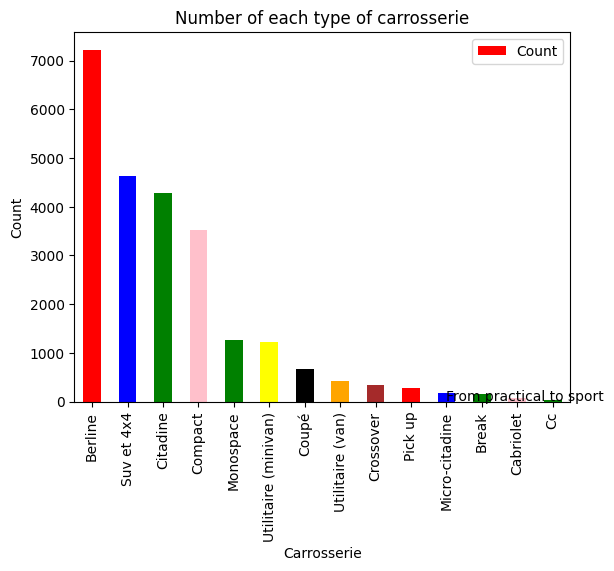

In [141]:
Carross_count.plot(kind="bar",x="Carrosserie",y="Count",color=["red","blue","green","pink","green","yellow","black","orange","brown"])
plt.ylabel("Count")
plt.title("Number of each type of carrosserie")
plt.annotate(text="From practical to sport",
    xy=(12,12),
    xytext=(10,10),
    xycoords='data',
    textcoords=None,
    arrowprops=None,)
plt.show()

In [148]:
fig=px.bar(Carross_count,x="Carrosserie",y="Count",color="Carrosserie")
"""fig.add_annotation(text="from pratical type to sport type",bgcolor="yellow",
                  arrowcolor=None,
    arrowhead=True,
    arrowside='end',
    arrowsize=None,
    arrowwidth=None,)
"""

'fig.add_annotation(text="from pratical type to sport type",bgcolor="yellow",\n                  arrowcolor=None,\n    arrowhead=True,\n    arrowside=\'end\',\n    arrowsize=None,\n    arrowwidth=None,)\n'